Task-4_Car Price Prediction with Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib.

In [4]:
data = pd.read_csv("/content/car data.csv")


In [5]:
data

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
# The isnull() method is used to check and manage NULL values in a data frame.
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [7]:
# Pandas describe() is used to view some basic statistical details of a data frame or a series of numeric values.
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
# Pandas info() function is used to get a concise summary of the dataframe.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [11]:
data.sample()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
158,Honda Dream Yuga,2017,0.48,0.54,8600,Petrol,Individual,Manual,0


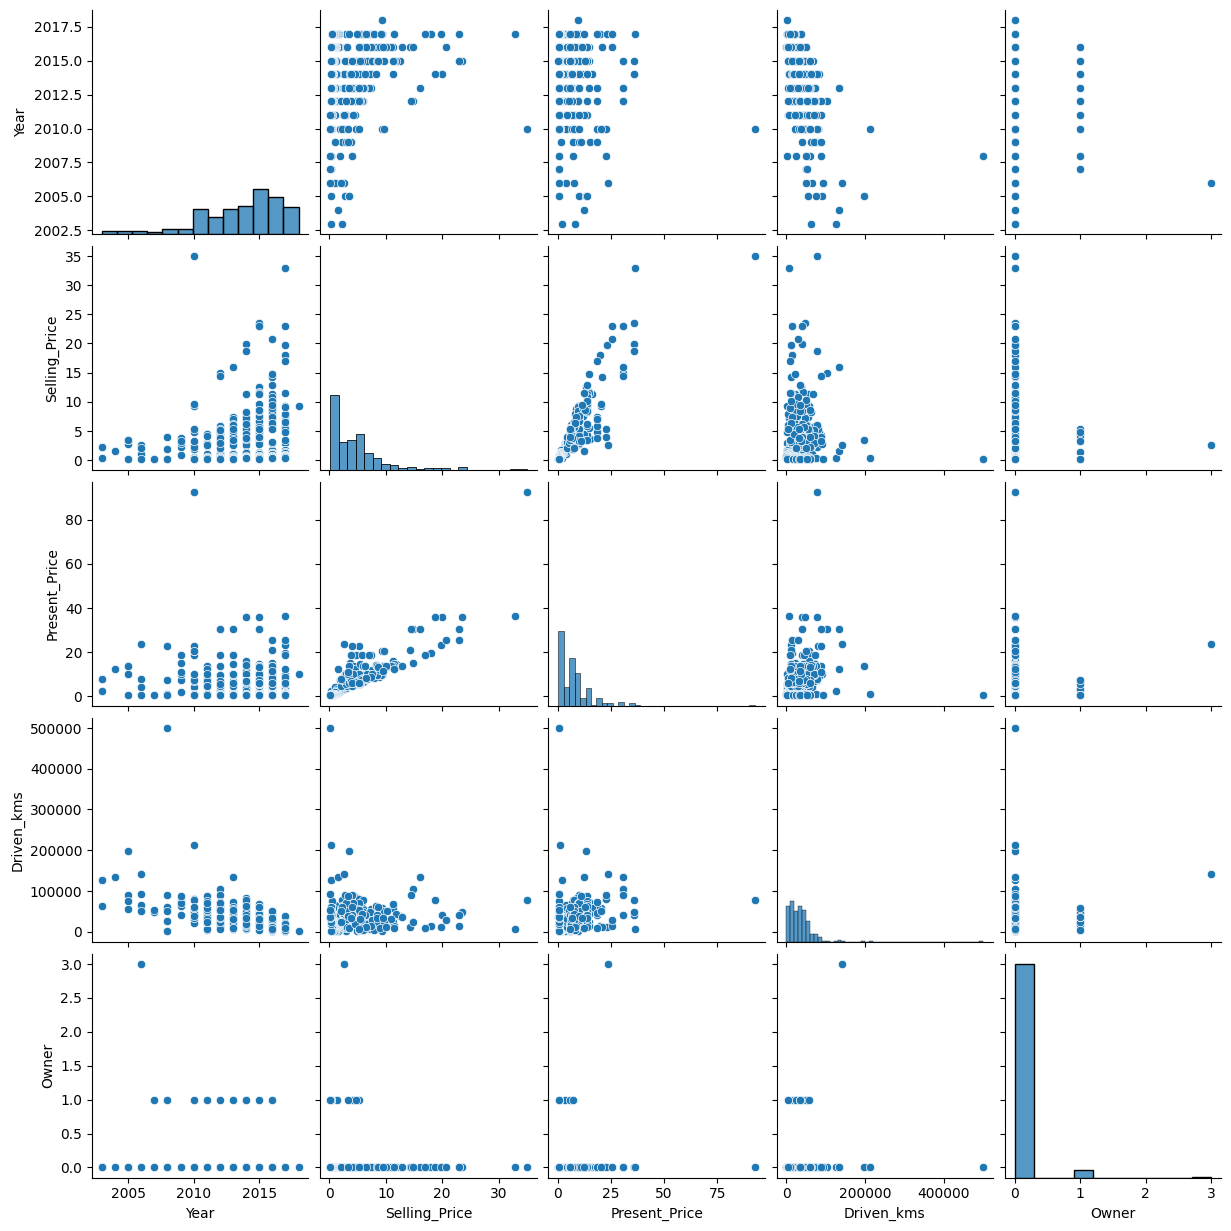

In [12]:
sns.pairplot(data)

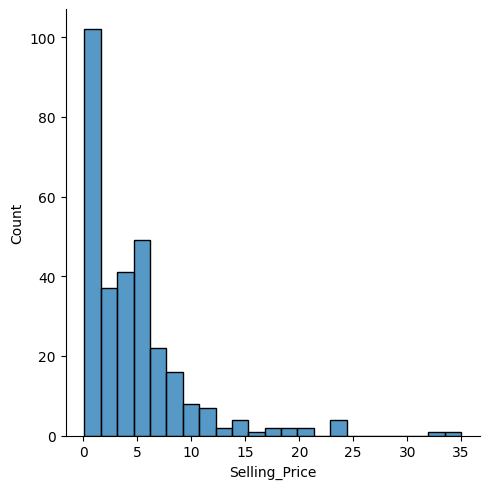

In [13]:
sns.displot(data['Selling_Price'])

In [20]:
X = data[["Car_Name","Year","Present_Price","Driven_kms",
          "Fuel_Type","Selling_type","Transmission","Owner"]]

y = data['Selling_Price']

# Feature Engineering
X['Car_Age'] = 2026 - X['Year']

# Drop unnecessary columns
X = X.drop(['Car_Name', 'Year'], axis=1)

# Apply one-hot encoding
X = pd.get_dummies(X,
                  columns=['Fuel_Type', 'Selling_type', 'Transmission'],
                  drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lm = LinearRegression()

In [24]:
lm.fit(X_train,y_train)

LinearRegression()

In [25]:
#prit the intercept
print(lm.intercept_)

8.935449081758387


In [26]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Present_Price,0.427767
Driven_kms,-0.000005
Owner,0.813835
Car_Age,-0.459727
Fuel_Type_Diesel,2.512760
Fuel_Type_Petrol,0.307201
Selling_type_Individual,-1.390226
Transmission_Manual,-2.156756


In [27]:
predictions = lm.predict(X_test)

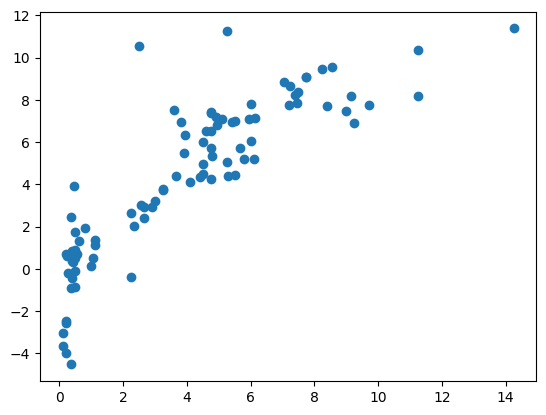

In [28]:
plt.scatter(y_test,predictions)

In [29]:
from sklearn import metrics

In [30]:
from sklearn.metrics import mean_squared_error, r2_score
print("R-squared:", r2_score(y_test, predictions))

R-squared: 0.6179105883444262


In [31]:
# Calculate MSE
mse = mean_squared_error(y_test, predictions)

In [34]:
compare_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
display(compare_df.head(10))

,Actual,Predicted
176,0.35,-0.897311
253,7.20,7.775657
12,7.50,8.364545
16,7.25,8.646913
193,0.20,0.694117
252,5.40,6.949841
244,5.95,7.097172
285,7.40,8.207999
147,0.55,0.715286
231,9.25,6.896244
